# TABLA HECHOS

## 1. IMPORTACIÓN LIBRERÍAS

In [1]:
# ============================================================
# 0. IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyarrow as pa
import os
import warnings
import gc
from pathlib import Path

# Visualización
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_colwidth', 80)

print('✅ Librerías importadas correctamente')
print(f'  pandas  {pd.__version__}')
print(f'  numpy   {np.__version__}')
print(f'  pyarrow {pa.__version__}')

✅ Librerías importadas correctamente
  pandas  2.3.3
  numpy   2.0.2
  pyarrow 23.0.1


## 2. DECLARACIÓN DE RUTAS

In [2]:
# ============================================================
# 1. DECLARACIÓN DE RUTAS
# Adaptar BASE_DIR según entorno (Kaggle / local / Colab)
# ============================================================

def detectar_entorno():
    """Detecta si se está ejecutando en Kaggle, Colab o local."""
    if os.path.exists('/kaggle/input'):
        return 'kaggle'
    elif 'google.colab' in str(globals()):
        return 'colab'
    else:
        return 'local'

ENTORNO = detectar_entorno()
print(f'Entorno detectado: {ENTORNO}')

# ── Rutas de entrada ────────────────────────────────────────
# En Kaggle: ajustar los nombres de dataset según el slug del dataset añadido
if ENTORNO == 'kaggle':
    BASE_DEFUNCIONES = '/kaggle/input/datasets/nicolasacostaa/defunciones-atribuibles-sistema-salud-colombia/df_defunciones_atribuibles.parquet'
    BASE_GIROS       = '/kaggle/input/datasets/geraldinelaverde/giros-final/Giros_final.parquet'
    BASE_RIPS        = '/kaggle/input/datasets/geraldinelaverde/rips-final/df_rips_final.parquet'
    BASE_SIVIGILA    = '/kaggle/input/datasets/mateotorrest/df-sivigila-limpio-2021/df_SIVIGILA_limpio (1).parquet'
    BASE_BDUA        = '/kaggle/input/datasets/mateotorrest/df-bdua-limpio/df_BDUA_limpio.parquet'
    BASE_POBLACION   = '/kaggle/input/datasets/nicolasacostaa/poblacion-colombia-dane/df_poblacion_colombia.parquet'
    BASE_DIVIPOLA    = '/kaggle/input/datasets/nicolasacostaa/divipola-actualizada-2025/divipola_cabeceras_centros_poblados.parquet'
    OUTPUT_DIR       = '/kaggle/working/'
else:
    # Local / Colab — ajustar BASE_INPUT
    BASE_INPUT       = Path('./data')   # Cambiar según ruta local
    BASE_DEFUNCIONES = BASE_INPUT / 'df_defunciones_atribuibles.parquet'
    BASE_GIROS       = BASE_INPUT / 'Giros_final.parquet'
    BASE_RIPS        = BASE_INPUT / 'df_rips_final.parquet'
    BASE_SIVIGILA    = BASE_INPUT / 'df_SIVIGILA_limpio__1_.parquet'
    BASE_BDUA        = BASE_INPUT / 'df_BDUA_limpio.parquet'
    BASE_POBLACION   = BASE_INPUT / 'df_poblacion_colombia.parquet'
    BASE_DIVIPOLA    = BASE_INPUT / 'divipola_cabeceras_centros_poblados.parquet'
    OUTPUT_DIR       = Path('./output')
    OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_TABLA_HECHOS = os.path.join(str(OUTPUT_DIR), 'tabla_hechos_salud_colombia.parquet')

# ── Kaggle dataset links (columna E del Excel) ──────────────
KAGGLE_LINKS = {
    'defunciones': 'https://www.kaggle.com/datasets/nicolasacostaa/defunciones',
    'giros'      : 'https://www.kaggle.com/datasets/geraldinelaverde/giros-final',
    'rips'       : 'https://www.kaggle.com/datasets/geraldinelaverde/rips-final',
    'sivigila'   : 'https://www.kaggle.com/datasets/mateotorrest/df-sivigila-limpio-2021',
    'bdua'       : 'https://www.kaggle.com/datasets/mateotorrest/df-bdua-limpio',
    'poblacion'  : 'https://www.kaggle.com/datasets/nicolasacostaa/poblacion-colombia',
    'divipola'   : 'https://www.kaggle.com/datasets/nicolasacostaa/divipola-actualizada-2025',
}

print('\n📂 Rutas configuradas:')
for nombre, path in [
    ('Defunciones', BASE_DEFUNCIONES), ('Giros', BASE_GIROS),
    ('RIPS', BASE_RIPS), ('SIVIGILA', BASE_SIVIGILA),
    ('BDUA', BASE_BDUA), ('Población', BASE_POBLACION), ('DIVIPOLA', BASE_DIVIPOLA)
]:
    existe = '✅' if os.path.exists(str(path)) else '❌'
    print(f'  {existe} {nombre}: {path}')

print(f'\n📤 Output: {OUTPUT_TABLA_HECHOS}')

Entorno detectado: kaggle

📂 Rutas configuradas:
  ✅ Defunciones: /kaggle/input/datasets/nicolasacostaa/defunciones-atribuibles-sistema-salud-colombia/df_defunciones_atribuibles.parquet
  ✅ Giros: /kaggle/input/datasets/geraldinelaverde/giros-final/Giros_final.parquet
  ✅ RIPS: /kaggle/input/datasets/geraldinelaverde/rips-final/df_rips_final.parquet
  ✅ SIVIGILA: /kaggle/input/datasets/mateotorrest/df-sivigila-limpio-2021/df_SIVIGILA_limpio (1).parquet
  ✅ BDUA: /kaggle/input/datasets/mateotorrest/df-bdua-limpio/df_BDUA_limpio.parquet
  ✅ Población: /kaggle/input/datasets/nicolasacostaa/poblacion-colombia-dane/df_poblacion_colombia.parquet
  ✅ DIVIPOLA: /kaggle/input/datasets/nicolasacostaa/divipola-actualizada-2025/divipola_cabeceras_centros_poblados.parquet

📤 Output: /kaggle/working/tabla_hechos_salud_colombia.parquet


## 3. FUNCIONES DE UTILIDAD

In [3]:
# ============================================================
# 3. FUNCIONES DE UTILIDAD COMUNES
# ============================================================

def normalizar_cod_muni(serie, n_digitos=5):
    """
    Normaliza códigos de municipio a string de n dígitos con cero izquierdo.
    Acepta int, float o string. Elimina decimales si vienen como float.
    Ejemplo: 5001 → '05001' | 5001.0 → '05001'
    """
    return (
        serie
        .fillna(-1)
        .astype(float)
        .astype(int)
        .astype(str)
        .str.zfill(n_digitos)
        .replace('-0001', np.nan)
        .replace('00000', np.nan)
    )


def normalizar_cod_dpto(serie, n_digitos=2):
    """
    Normaliza código de departamento a 2 dígitos con cero izquierdo.
    Extrae los primeros 2 dígitos del código de municipio si hace falta.
    """
    return (
        serie
        .fillna(-1)
        .astype(float)
        .astype(int)
        .astype(str)
        .str.zfill(n_digitos)
        .replace('-1', np.nan)
    )


def validar_mes(serie, nombre_col='MES'):
    """
    Valida la columna de mes. Valores fuera de [1,12] o iguales a 1 con
    ausencia de variación total se consideran datos 'quemados' (sin info real).
    Retorna la serie limpia y un reporte de anomalías.
    """
    reporte = {}
    validos = serie.between(1, 12, inclusive='both')
    reporte['invalidos'] = (~validos).sum()
    reporte['nulos_originales'] = serie.isna().sum()

    # Detectar mes quemado (solo valor 1 en toda la columna)
    unicos = serie.dropna().unique()
    if len(unicos) == 1 and unicos[0] == 1:
        reporte['advertencia'] = (
            f'⚠️  {nombre_col}: solo contiene el valor 1 — '
            'posible mes quemado por ausencia de información mensual real.'
        )
    return serie.where(validos), reporte


def validar_anio(serie, anio_min=1979, anio_max=2042, nombre_col='ANIO'):
    """Valida que los años estén en el rango esperado y reporta anomalías."""
    validos = serie.between(anio_min, anio_max, inclusive='both')
    n_invalidos = (~validos).sum()
    if n_invalidos > 0:
        print(f'  ⚠️  {nombre_col}: {n_invalidos} valores fuera de [{anio_min},{anio_max}]')
    return serie.where(validos)


def info_df(df, nombre='DataFrame'):
    """Imprime resumen compacto de un DataFrame."""
    print(f'\n📊 [{nombre}]')
    print(f'  Filas × Columnas : {df.shape[0]:,} × {df.shape[1]}')
    print(f'  Memoria estimada : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    if len(nulos) > 0:
        print(f'  Columnas con nulos: {len(nulos)}')
        for col, n in nulos.items():
            pct = n / len(df) * 100
            print(f'    {col}: {n:,} ({pct:.1f}%)')


def leer_parquet_schema(path):
    """Lee solo el schema de un parquet sin cargar datos."""
    meta = pq.read_metadata(str(path))
    schema = pq.read_schema(str(path))
    print(f'  Filas: {meta.num_rows:,} | Columnas: {len(schema)}')
    return meta, schema


print('✅ Funciones de utilidad definidas')

✅ Funciones de utilidad definidas


## 4. LECTURA Y LIMPIEZA POR FUENTE

### 4.1. DIVIPOLA

In [4]:
# ============================================================
# 4.1 DIVIPOLA — Dimensión geográfica de referencia
# ============================================================

def cargar_divipola(path):
    """
    Carga DIVIPOLA y construye tabla de municipios únicos con coordenadas.
    Se agrega por municipio (COD_MPIO) tomando la cabecera municipal.
    """
    cols = ['COD_DPTO', 'NOM_DPTO', 'COD_MPIO', 'NOM_MPIO',
            'ÁREA_GEOGRÁFICA', 'LONGITUD', 'LATITUD', 'GEOMETRIA_PUNTO_WKT']
    df = pd.read_parquet(str(path), columns=cols)

    # Normalizar códigos
    df['COD_MPIO'] = df['COD_MPIO'].astype(str).str.zfill(5)
    df['COD_DPTO'] = df['COD_DPTO'].astype(str).str.zfill(2)

    # Priorizar cabecera municipal para coordenadas
    cabeceras = df[df['ÁREA_GEOGRÁFICA'] == 'Cabecera Municipal'].copy()
    resto     = df[df['ÁREA_GEOGRÁFICA'] != 'Cabecera Municipal']

    # Municipios sin cabecera — tomar primer registro disponible
    municipios_sin_cabecera = set(df['COD_MPIO']) - set(cabeceras['COD_MPIO'])
    resto_filtrado = resto[resto['COD_MPIO'].isin(municipios_sin_cabecera)]

    geo = (
        pd.concat([cabeceras, resto_filtrado])
        .groupby('COD_MPIO', as_index=False)
        .agg(
            COD_DPTO           = ('COD_DPTO', 'first'),
            NOM_DPTO           = ('NOM_DPTO', 'first'),
            NOM_MPIO           = ('NOM_MPIO', 'first'),
            LONGITUD           = ('LONGITUD', 'first'),
            LATITUD            = ('LATITUD', 'first'),
            GEOMETRIA_PUNTO_WKT= ('GEOMETRIA_PUNTO_WKT', 'first'),
        )
    )
    info_df(geo, 'DIVIPOLA')
    return geo


divipola = cargar_divipola(BASE_DIVIPOLA)
print(f'\n  Municipios únicos en DIVIPOLA: {divipola.shape[0]:,}')
divipola.head(3)


📊 [DIVIPOLA]
  Filas × Columnas : 1,122 × 7
  Memoria estimada : 0.4 MB

  Municipios únicos en DIVIPOLA: 1,122


,COD_MPIO,COD_DPTO,NOM_DPTO,NOM_MPIO,LONGITUD,LATITUD,GEOMETRIA_PUNTO_WKT
0,05001,05,ANTIOQUIA,MEDELLÍN,-75.58,6.25,POINT (-75.581775 6.246631)
1,05002,05,ANTIOQUIA,ABEJORRAL,-75.43,5.79,POINT (-75.428739 5.789315)
2,05004,05,ANTIOQUIA,ABRIAQUÍ,-76.06,6.63,POINT (-76.064304 6.632282)


### 4.2. POBLACIÓN

In [5]:
# ============================================================
# 4.2 POBLACIÓN — Proyecciones DANE por municipio-año
# ============================================================

def cargar_poblacion(path, anio_min=2009, anio_max=2024):
    """
    Agrega población total por municipio-año.
    Solo se leen los años relevantes para el análisis (rango de las otras fuentes).
    TIPO=0: datos reales / TIPO=1: proyecciones — se retiene el indicador.
    """
    cols = ['DP', 'COD_MPIO', 'AÑO', 'POBLACION', 'TIPO', 'GENERO', 'ÁREA GEOGRÁFICA']
    
    # Leer en chunks para archivos grandes
    chunks = []
    pf = pq.ParquetFile(str(path))
    for batch in pf.iter_batches(batch_size=500_000, columns=cols):
        df_chunk = batch.to_pandas()
        df_chunk = df_chunk[
            df_chunk['AÑO'].between(anio_min, anio_max)
        ]
        chunks.append(df_chunk)
    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()

    df['COD_MPIO'] = df['COD_MPIO'].astype(str).str.zfill(5)
    df['COD_DPTO'] = df['DP'].astype(str).str.zfill(2)
    df['ANIO']     = df['AÑO'].astype(int)

    # Validar año
    df['ANIO'] = validar_anio(df['ANIO'], anio_min, anio_max, 'ANIO_POBLACION')

    # Agregar por municipio-año
    pop = (
        df.groupby(['COD_MPIO', 'ANIO'], as_index=False)
        .agg(
            POBLACION_TOTAL  = ('POBLACION', 'sum'),
            TIPO_DATO_POB    = ('TIPO', 'first'),   # 0=real, 1=proyección
        )
    )

    info_df(pop, 'POBLACIÓN')
    print(f'  Años cubiertos: {pop["ANIO"].min()} – {pop["ANIO"].max()}')
    print(f'  Municipios únicos: {pop["COD_MPIO"].nunique():,}')
    return pop


df_poblacion = cargar_poblacion(BASE_POBLACION)
df_poblacion.head(3)


📊 [POBLACIÓN]
  Filas × Columnas : 17,959 × 4
  Memoria estimada : 1.4 MB
  Años cubiertos: 2009 – 2024
  Municipios únicos: 1,123


,COD_MPIO,ANIO,POBLACION_TOTAL,TIPO_DATO_POB
0,05001,2009,2157094,0
1,05001,2010,2185539,0
2,05001,2011,2213549,0


### 4.3. DEFUNCIONES

In [6]:
# ============================================================
# 4.3 DEFUNCIONES — Muertes atribuibles
# ============================================================

def cargar_defunciones(path):
    """
    Agrega defunciones por municipio-año.
    - TOTAL_FALLECIDOS: todas las defunciones registradas
    - MUERTES_ATRIBUIBLES: aquellas donde atribuible_sistema_salud = 1
    - FLG_MUERTE_ATRIBUIBLE: flag de la tabla de hechos (se calcula como tasa)
    Fechas: la columna `fecha` tiene timestamp; se extrae el año de ahí.
    ADVERTENCIA: si MES viene quemado en 1, se usa año sin desagregación mensual.
    """
    cols = ['cod_muni', 'doc_dep', 'fecha', 'Número de Fallecidos', 'atribuible_sistema_salud',
            'departamento', 'municipio', 'Códigos CIE-10', 'AGRUPACIÓN EDADES 1', 'SEXO']
    df = pd.read_parquet(str(path), columns=cols)

    # Normalizar código municipio
    df['COD_MPIO'] = df['cod_muni'].astype(str).str.zfill(5)
    df['COD_DPTO'] = df['doc_dep'].astype(str).str.zfill(2)

    # Extraer año de fecha (columna timestamp)
    df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
    df['ANIO']  = df['fecha'].dt.year
    df['ANIO']  = validar_anio(df['ANIO'], 1979, 2024, 'ANIO_DEFUNCIONES')

    # Validación: mes siempre = 1 en defunciones agrupadas → esperado
    print('  ℹ️  Defunciones: la columna fecha agrupa anualmente (mes=01 por diseño del dataset).')

    df['N_FALLECIDOS']   = df['Número de Fallecidos'].fillna(0).astype(int)
    df['ES_ATRIBUIBLE']  = df['atribuible_sistema_salud'].fillna(0).astype(int)
    df['MUERTES_ATR']    = df['N_FALLECIDOS'] * df['ES_ATRIBUIBLE']

    # Agregar por municipio-año
    def_agg = (
        df.groupby(['COD_MPIO', 'ANIO'], as_index=False)
        .agg(
            TOTAL_FALLECIDOS   = ('N_FALLECIDOS', 'sum'),
            MUERTES_ATRIBUIBLES= ('MUERTES_ATR', 'sum'),
            N_REGISTROS_DEF    = ('N_FALLECIDOS', 'count'),
        )
    )
    def_agg['PCT_ATRIBUIBLE'] = np.where(
        def_agg['TOTAL_FALLECIDOS'] > 0,
        def_agg['MUERTES_ATRIBUIBLES'] / def_agg['TOTAL_FALLECIDOS'],
        np.nan
    )
    info_df(def_agg, 'DEFUNCIONES')
    print(f'  Años: {def_agg["ANIO"].min()} – {def_agg["ANIO"].max()}')
    print(f'  Total muertes atribuibles: {def_agg["MUERTES_ATRIBUIBLES"].sum():,}')
    return def_agg


df_defunciones = cargar_defunciones(BASE_DEFUNCIONES)
df_defunciones.head(3)

  ℹ️  Defunciones: la columna fecha agrupa anualmente (mes=01 por diseño del dataset).

📊 [DEFUNCIONES]
  Filas × Columnas : 48,588 × 6
  Memoria estimada : 4.4 MB
  Años: 1979 – 2024
  Total muertes atribuibles: 3,661,950


,COD_MPIO,ANIO,TOTAL_FALLECIDOS,MUERTES_ATRIBUIBLES,N_REGISTROS_DEF,PCT_ATRIBUIBLE
0,05001,1979,8835,3463,8253,0.39
1,05001,1980,9455,3661,8679,0.39
2,05001,1981,9798,3926,8929,0.40


### 4.4. RIPS

In [7]:
# ============================================================
# 4.4 RIPS — Registros individuales de prestación de servicios
# ============================================================

def cargar_rips(path, batch_size=2_000_000):
    """
    Lee RIPS en chunks (38M filas) y agrega por municipio-año-tipo de atención.
    Pivota TipoAtencion como columnas: CONSULTAS, URGENCIAS, HOSPITALIZACION, PROCEDIMIENTOS.
    Valida que MES esté en [1,12].
    """
    cols_rips = ['ANO', 'MES', 'CÓDIGO MUNICIPIO', 'CÓDIGO DEPARTAMENTO',
                 'TipoAtencion', 'NumeroAtenciones']

    agg_chunks = []
    pf = pq.ParquetFile(str(path))
    for i, batch in enumerate(pf.iter_batches(batch_size=batch_size, columns=cols_rips)):
        df_chunk = batch.to_pandas()

        # Normalizar
        df_chunk['COD_MPIO'] = df_chunk['CÓDIGO MUNICIPIO'].astype(str).str.zfill(5)
        df_chunk['ANIO']     = pd.to_numeric(df_chunk['ANO'], errors='coerce').astype('Int64')

        # Validar MES
        mes_clean, rep = validar_mes(pd.to_numeric(df_chunk['MES'], errors='coerce'), 'MES_RIPS')
        if rep.get('advertencia'):
            print(f'  Chunk {i}: {rep["advertencia"]}')

        # Normalizar tipo atención
        df_chunk['TIPO'] = (
            df_chunk['TipoAtencion'].str.upper()
            .str.strip()
            .str.replace(' ', '_', regex=False)
        )

        # Agregar
        chunk_agg = (
            df_chunk.groupby(['COD_MPIO', 'ANIO', 'TIPO'], as_index=False)
            ['NumeroAtenciones'].sum()
        )
        agg_chunks.append(chunk_agg)

    df_rips = pd.concat(agg_chunks, ignore_index=True)
    del agg_chunks
    gc.collect()

    # Segunda agregación
    df_rips = (
        df_rips.groupby(['COD_MPIO', 'ANIO', 'TIPO'], as_index=False)
        ['NumeroAtenciones'].sum()
    )

    # Pivot: una columna por tipo de atención
    df_pivot = df_rips.pivot_table(
        index=['COD_MPIO', 'ANIO'],
        columns='TIPO',
        values='NumeroAtenciones',
        aggfunc='sum',
        fill_value=0
    ).reset_index()
    df_pivot.columns.name = None

    # Renombrar para estandarizar
    mapeo = {
        c: f'RIPS_{c}' for c in df_pivot.columns if c not in ('COD_MPIO', 'ANIO')
    }
    df_pivot.rename(columns=mapeo, inplace=True)

    # Total atenciones
    cols_rips_num = [c for c in df_pivot.columns if c.startswith('RIPS_')]
    df_pivot['TOTAL_ATENCIONES_RIPS'] = df_pivot[cols_rips_num].sum(axis=1)

    info_df(df_pivot, 'RIPS')
    print(f'  Años: {df_pivot["ANIO"].min()} – {df_pivot["ANIO"].max()}')
    print(f'  Tipos de atención: {[c.replace("RIPS_","") for c in cols_rips_num]}')
    return df_pivot


df_rips = cargar_rips(BASE_RIPS)
df_rips.head(3)

  Chunk 0: ⚠️  MES_RIPS: solo contiene el valor 1 — posible mes quemado por ausencia de información mensual real.
  Chunk 1: ⚠️  MES_RIPS: solo contiene el valor 1 — posible mes quemado por ausencia de información mensual real.
  Chunk 2: ⚠️  MES_RIPS: solo contiene el valor 1 — posible mes quemado por ausencia de información mensual real.
  Chunk 3: ⚠️  MES_RIPS: solo contiene el valor 1 — posible mes quemado por ausencia de información mensual real.
  Chunk 4: ⚠️  MES_RIPS: solo contiene el valor 1 — posible mes quemado por ausencia de información mensual real.
  Chunk 5: ⚠️  MES_RIPS: solo contiene el valor 1 — posible mes quemado por ausencia de información mensual real.
  Chunk 6: ⚠️  MES_RIPS: solo contiene el valor 1 — posible mes quemado por ausencia de información mensual real.
  Chunk 7: ⚠️  MES_RIPS: solo contiene el valor 1 — posible mes quemado por ausencia de información mensual real.
  Chunk 8: ⚠️  MES_RIPS: solo contiene el valor 1 — posible mes quemado por ausencia de 

,COD_MPIO,ANIO,RIPS_CONSULTAS,RIPS_HOSPITALIZACIONES,RIPS_PROCEDIMIENTOS_DE_SALUD,RIPS_URGENCIAS,TOTAL_ATENCIONES_RIPS
0,-1 -,2009,333761,123862,64721,139495,661839
1,-1 -,2010,1592006,6309,4137270,70947,5806532
2,-1 -,2011,3116575,91533,249900,115907,3573915


### 4.5. GIROS

In [8]:
# ============================================================
# 3.5 GIROS SGP — Recursos financieros a municipios
# ============================================================

def cargar_giros(path):
    """
    Agrega valor girado por municipio-año.
    Filtra pagos atípicos (es_atipico=True) y los reporta.
    Valida coherencia de MES y año.
    Nota: MES y ANO vienen separados; se construye fecha completa solo si MES válido.
    """
    df = pd.read_parquet(str(path))

    # Normalizar código municipio (viene como float: 5001.0 → '05001')
    df['COD_MPIO'] = normalizar_cod_muni(df['CÓDIGO MUNICIPIO'])

    # Validar año y mes
    df['ANIO'] = pd.to_numeric(df['ANO'], errors='coerce').astype('Int64')
    df['ANIO'] = validar_anio(df['ANIO'], 2015, 2023, 'ANIO_GIROS')

    mes_clean, rep = validar_mes(pd.to_numeric(df['MES'], errors='coerce'), 'MES_GIROS')
    if rep.get('advertencia'):
        print(f'  {rep["advertencia"]}')
    df['MES_GIROS'] = mes_clean

    # Reporte de atípicos
    n_atipicos = df['es_atipico'].sum()
    print(f'  ℹ️  Registros atípicos en GIROS: {n_atipicos:,} ({n_atipicos/len(df)*100:.1f}%)')

    # Agregar por municipio-año (incluir y excluir atípicos)
    giros_agg = (
        df.groupby(['COD_MPIO', 'ANIO'], as_index=False)
        .agg(
            VALOR_GIRADO_TOTAL    = ('Valor Girado', 'sum'),
            VALOR_GIRADO_NORMAL   = ('Valor Girado', lambda x: x[~df.loc[x.index, 'es_atipico']].sum()),
            N_GIROS               = ('Valor Girado', 'count'),
            N_GIROS_ATIPICOS      = ('es_atipico', 'sum'),
        )
    )
    giros_agg['GIRO_PROMEDIO_MES'] = giros_agg['VALOR_GIRADO_TOTAL'] / 12

    info_df(giros_agg, 'GIROS')
    print(f'  Años: {giros_agg["ANIO"].min()} – {giros_agg["ANIO"].max()}')
    return giros_agg


df_giros = cargar_giros(BASE_GIROS)
df_giros.head(3)

  ℹ️  Registros atípicos en GIROS: 6,339 (12.7%)

📊 [GIROS]
  Filas × Columnas : 4,867 × 7
  Memoria estimada : 0.5 MB
  Años: 2015 – 2023


,COD_MPIO,ANIO,VALOR_GIRADO_TOTAL,VALOR_GIRADO_NORMAL,N_GIROS,N_GIROS_ATIPICOS,GIRO_PROMEDIO_MES
0,05001,2015,16759055247,0,12,12,"1,396,587,937.25"
1,05001,2016,18616413249,0,12,12,"1,551,367,770.75"
2,05001,2019,13807544936,0,8,8,"1,150,628,744.67"


### 4.6. SIVIGILA

In [9]:
# ============================================================
# 3.6 SIVIGILA — Vigilancia en salud pública
# ============================================================

def cargar_sivigila(path):
    """
    Agrega eventos SIVIGILA por municipio-año.
    FECHA_SIVIGILA: formato 'DD/MM/YYYY' — se parsea correctamente.
    SEMANA: validar rango [1, 53]; semana=1 con sin variación → posible quemado.
    Solo año 2021 disponible → se indicará en la tabla de hechos como restricción.
    """
    df = pd.read_parquet(str(path))

    # Normalizar código municipio (viene como float: 5031.0 → '05031')
    df['COD_MPIO'] = normalizar_cod_muni(df['cod_muni'])

    # Validar y parsear FECHA_SIVIGILA
    df['FECHA_SIVIGILA'] = pd.to_datetime(df['FECHA_SIVIGILA'], format='%d/%m/%Y', errors='coerce')
    df['ANIO_SIV']       = df['FECHA_SIVIGILA'].dt.year.fillna(df['ANO']).astype('Int64')
    df['ANIO_SIV']       = validar_anio(df['ANIO_SIV'], 2019, 2024, 'ANIO_SIVIGILA')

    # Validar SEMANA
    semanas_validas = df['SEMANA'].between(1, 53)
    n_invalidas     = (~semanas_validas).sum()
    if n_invalidas > 0:
        print(f'  ⚠️  SIVIGILA SEMANA fuera de [1,53]: {n_invalidas:,} registros')

    unicos_sem = df['SEMANA'].dropna().unique()
    if len(unicos_sem) == 1 and unicos_sem[0] == 1:
        print('  ⚠️  SIVIGILA SEMANA = 1 en todos los registros → posible campo quemado.')

    # Agregar por municipio-año
    siv_agg = (
        df.groupby(['COD_MPIO', 'ANIO_SIV'], as_index=False)
        .agg(
            TOTAL_EVENTOS_SIVIGILA = ('conteo', 'sum'),
            N_TIPOS_EVENTO         = ('COD_EVE', 'nunique'),
        )
        .rename(columns={'ANIO_SIV': 'ANIO'})
    )

    info_df(siv_agg, 'SIVIGILA')
    print(f'  Cobertura: solo año(s) {siv_agg["ANIO"].unique()} — se usará como feature de corte temporal.')
    return siv_agg


df_sivigila = cargar_sivigila(BASE_SIVIGILA)
df_sivigila.head(3)


📊 [SIVIGILA]
  Filas × Columnas : 867 × 4
  Memoria estimada : 0.1 MB
  Cobertura: solo año(s) <IntegerArray>
[2021]
Length: 1, dtype: Int64 — se usará como feature de corte temporal.


,COD_MPIO,ANIO,TOTAL_EVENTOS_SIVIGILA,N_TIPOS_EVENTO
0,05001,2021,30304,59
1,05002,2021,221,22
2,05004,2021,26,11


### 4.7. BDUA

In [10]:
# ============================================================
# 3.7 BDUA — Afiliados al régimen subsidiado
# ============================================================

def cargar_bdua(path):
    """
    Agrega BDUA por municipio.
    BDUA no tiene año explícito — es un corte transversal.
    Se calcula: total afiliados, % por régimen, distribución por género.
    NOTA: sin año → se usará como feature estática (join solo por municipio).
    """
    df = pd.read_parquet(str(path))

    # Normalizar código municipio
    df['COD_MPIO'] = normalizar_cod_muni(df['cod_muni'])

    # Filtar nulos en COD_MPIO
    n_antes = len(df)
    df = df[df['COD_MPIO'].notna()]
    print(f'  BDUA: eliminados {n_antes - len(df):,} registros sin código municipio')

    # Subtotales por género
    bdua_gen = (
        df.groupby(['COD_MPIO', 'Genero'], as_index=False)['cantidad'].sum()
        .pivot(index='COD_MPIO', columns='Genero', values='cantidad')
        .fillna(0)
        .reset_index()
    )
    bdua_gen.columns = ['COD_MPIO'] + [f'BDUA_{c.upper()}' for c in bdua_gen.columns if c != 'COD_MPIO']

    # Total afiliados
    bdua_total = (
        df.groupby('COD_MPIO', as_index=False)
        .agg(
            BDUA_TOTAL_AFILIADOS   = ('cantidad', 'sum'),
            BDUA_N_ENTIDADES       = ('Código de la entidad', 'nunique'),
        )
    )

    # % subsidiado vs contributivo
    bdua_reg = (
        df.groupby(['COD_MPIO', 'Régimen al que pertenece'], as_index=False)['cantidad'].sum()
        .pivot(index='COD_MPIO', columns='Régimen al que pertenece', values='cantidad')
        .fillna(0)
        .reset_index()
    )
    bdua_reg.columns = ['COD_MPIO'] + [
        f'BDUA_REG_{c.upper().replace(" ","_")}' for c in bdua_reg.columns if c != 'COD_MPIO'
    ]

    bdua_final = bdua_total.merge(bdua_gen, on='COD_MPIO', how='left')
    bdua_final = bdua_final.merge(bdua_reg, on='COD_MPIO', how='left')

    info_df(bdua_final, 'BDUA')
    print('  ℹ️  BDUA sin año explícito — se usará como feature estática por municipio.')
    return bdua_final


df_bdua = cargar_bdua(BASE_BDUA)
df_bdua.head(3)

  BDUA: eliminados 0 registros sin código municipio

📊 [BDUA]
  Filas × Columnas : 1,007 × 6
  Memoria estimada : 0.1 MB
  ℹ️  BDUA sin año explícito — se usará como feature estática por municipio.


,COD_MPIO,BDUA_TOTAL_AFILIADOS,BDUA_N_ENTIDADES,BDUA_FEMENINO,BDUA_MASCULINO,BDUA_REG_SUBSIDIADO
0,05001,868890,14,447055,421835,868890
1,05002,11814,5,5800,6014,11814
2,05004,1367,3,651,716,1367


## 5. CONSTRUCCIÓN TABLA DE HECHOS

In [11]:
# ============================================================
# 5. CONSTRUCCIÓN DE LA TABLA DE HECHOS PRINCIPAL
# Granularidad: MUNICIPIO × AÑO
# Llave: COD_MPIO (5 dígitos) + ANIO
# ============================================================

def construir_tabla_hechos(df_def, df_rips, df_giros, df_siv, df_bdua, df_pob, df_geo):
    """
    Une todas las fuentes bajo la granularidad municipio-año.
    Estrategia de joins:
      1. Base: defunciones (tiene mayor cobertura histórica y es el KPI principal)
      2. LEFT JOIN: RIPS, GIROS, SIVIGILA, POBLACIÓN → preserva todos los municipios
      3. LEFT JOIN estático: BDUA y DIVIPOLA (sin año)

    Rango de años final: definido por el cruce real entre fuentes.
    SIVIGILA solo cubre 2021 → aparecerá como NaN en otros años (esperado).
    BDUA es un corte transversal → se replca para todos los años (join solo por municipio).
    """

    print('🔗 Iniciando construcción de Tabla de Hechos...')

    # ── Paso 1: Base = Defunciones ─────────────────────────────────────────────
    hechos = df_def.copy()
    print(f'  Base (Defunciones): {len(hechos):,} filas')

    # ── Paso 2: JOIN Población ─────────────────────────────────────────────────
    hechos = hechos.merge(
        df_pob[['COD_MPIO', 'ANIO', 'POBLACION_TOTAL', 'TIPO_DATO_POB']],
        on=['COD_MPIO', 'ANIO'], how='left'
    )
    print(f'  Después JOIN Población: {len(hechos):,} filas')

    # ── Paso 3: JOIN RIPS ──────────────────────────────────────────────────────
    hechos = hechos.merge(df_rips, on=['COD_MPIO', 'ANIO'], how='left')
    print(f'  Después JOIN RIPS: {len(hechos):,} filas')

    # ── Paso 4: JOIN GIROS ─────────────────────────────────────────────────────
    hechos = hechos.merge(
        df_giros[['COD_MPIO', 'ANIO', 'VALOR_GIRADO_TOTAL', 'VALOR_GIRADO_NORMAL',
                  'N_GIROS', 'N_GIROS_ATIPICOS', 'GIRO_PROMEDIO_MES']],
        on=['COD_MPIO', 'ANIO'], how='left'
    )
    print(f'  Después JOIN GIROS: {len(hechos):,} filas')

    # ── Paso 5: JOIN SIVIGILA (solo 2021) ──────────────────────────────────────
    hechos = hechos.merge(df_siv, on=['COD_MPIO', 'ANIO'], how='left')
    print(f'  Después JOIN SIVIGILA: {len(hechos):,} filas (NaN esperados fuera de 2021)')

    # ── Paso 6: JOIN BDUA (estático — solo por municipio) ─────────────────────
    hechos = hechos.merge(df_bdua, on='COD_MPIO', how='left')
    print(f'  Después JOIN BDUA: {len(hechos):,} filas')

    # ── Paso 7: JOIN DIVIPOLA (geográfico estático) ────────────────────────────
    hechos = hechos.merge(
        df_geo[['COD_MPIO', 'COD_DPTO', 'NOM_DPTO', 'NOM_MPIO',
                'LONGITUD', 'LATITUD', 'GEOMETRIA_PUNTO_WKT']],
        on='COD_MPIO', how='left'
    )
    print(f'  Después JOIN DIVIPOLA: {len(hechos):,} filas')

    return hechos


df_hechos_raw = construir_tabla_hechos(
    df_defunciones, df_rips, df_giros,
    df_sivigila, df_bdua, df_poblacion, divipola
)
print(f'\n✅ Tabla raw: {df_hechos_raw.shape}')

🔗 Iniciando construcción de Tabla de Hechos...
  Base (Defunciones): 48,588 filas
  Después JOIN Población: 48,588 filas
  Después JOIN RIPS: 48,588 filas
  Después JOIN GIROS: 48,588 filas
  Después JOIN SIVIGILA: 48,588 filas (NaN esperados fuera de 2021)
  Después JOIN BDUA: 48,588 filas
  Después JOIN DIVIPOLA: 48,588 filas

✅ Tabla raw: (48588, 31)


## 6. INGENIERÍA DE CARACTERÍSTICAS E INDICADORES

In [12]:
# ============================================================
# 5. INGENIERÍA DE CARACTERÍSTICAS
# ============================================================

def calcular_indicadores(df):
    """
    Calcula KPIs e indicadores derivados para los modelos:
    - TASA_MORTALIDAD_EVITABLE_100K : variable objetivo del modelo de regresión
    - FLG_ZONA_ALTO_RIESGO          : variable objetivo del modelo de clasificación (umbral P80)
    - GIRO_PER_CAPITA               : recursos SGP por habitante
    - TASA_ATENCIONES_RIPS_100K     : capacidad del sistema de atención
    """
    d = df.copy()

    # Convertir columnas con nullable Int a float para evitar NA ambiguos en comparaciones
    for col in d.select_dtypes(include=['Int8','Int16','Int32','Int64']).columns:
        d[col] = d[col].astype('float64')

    # ── Tasas por 100k habitantes ─────────────────────────────
    pob_valida = d['POBLACION_TOTAL'].fillna(0) > 0

    d['TASA_MORTALIDAD_TOTAL_100K'] = np.where(
        pob_valida,
        d['TOTAL_FALLECIDOS'] / d['POBLACION_TOTAL'] * 100_000,
        np.nan
    )
    d['TASA_MORTALIDAD_EVITABLE_100K'] = np.where(
        pob_valida,
        d['MUERTES_ATRIBUIBLES'] / d['POBLACION_TOTAL'] * 100_000,
        np.nan
    )

    # ── Variable objetivo: Clasificación (Zona Alto Riesgo ≥ P80) ─
    p80 = d['TASA_MORTALIDAD_EVITABLE_100K'].quantile(0.80)
    d['FLG_ZONA_ALTO_RIESGO'] = np.where(
        d['TASA_MORTALIDAD_EVITABLE_100K'].notna(),
        (d['TASA_MORTALIDAD_EVITABLE_100K'] >= p80).astype(int),
        np.nan
    )
    print(f'  ℹ️  Umbral P80 para clasificación: {p80:.2f} muertes/100k')

    # ── Recursos per cápita ───────────────────────────────────
    d['GIRO_PER_CAPITA'] = np.where(
        pob_valida,
        d['VALOR_GIRADO_TOTAL'].fillna(0) / d['POBLACION_TOTAL'],
        np.nan
    )

    # ── Tasas de atención RIPS ────────────────────────────────
    if 'TOTAL_ATENCIONES_RIPS' in d.columns:
        d['TASA_ATENCIONES_RIPS_100K'] = np.where(
            pob_valida,
            d['TOTAL_ATENCIONES_RIPS'].fillna(0) / d['POBLACION_TOTAL'] * 100_000,
            np.nan
        )

    # ── % atenciones por tipo (FIX: evitar NA ambiguo en condición booleana) ──
    if 'TOTAL_ATENCIONES_RIPS' in d.columns:
        rips_valido = d['TOTAL_ATENCIONES_RIPS'].fillna(0) > 0   # máscara booleana pura
        cols_rips = [c for c in d.columns if c.startswith('RIPS_')]
        for col in cols_rips:
            pct_col = col.replace('RIPS_', 'PCT_') + '_100K'
            d[pct_col] = np.where(
                rips_valido,
                d[col].fillna(0) / d['TOTAL_ATENCIONES_RIPS'].replace(0, np.nan) * 100,
                np.nan
            )

    # ── Semestre ──────────────────────────────────────────────
    d['SEMESTRE'] = 1  # sin desagregación mensual en defunciones

    # ── Cobertura de afiliación ───────────────────────────────
    if 'BDUA_TOTAL_AFILIADOS' in d.columns:
        d['PCT_AFILIACION'] = np.where(
            pob_valida,
            np.minimum(d['BDUA_TOTAL_AFILIADOS'].fillna(0) / d['POBLACION_TOTAL'] * 100, 100),
            np.nan
        )

    # ── Densidad de eventos SIVIGILA ──────────────────────────
    if 'TOTAL_EVENTOS_SIVIGILA' in d.columns:
        d['TASA_SIVIGILA_100K'] = np.where(
            pob_valida,
            d['TOTAL_EVENTOS_SIVIGILA'].fillna(0) / d['POBLACION_TOTAL'] * 100_000,
            np.nan
        )

    return d


df_hechos = calcular_indicadores(df_hechos_raw)

# Ordenar columnas de forma lógica
COLS_ORDEN = [
    # Llaves
    'COD_MPIO', 'ANIO', 'COD_DPTO',
    # Dimensiones geográficas
    'NOM_DPTO', 'NOM_MPIO', 'LONGITUD', 'LATITUD', 'GEOMETRIA_PUNTO_WKT',
    # Variables objetivo (modelos)
    'TASA_MORTALIDAD_EVITABLE_100K', 'FLG_ZONA_ALTO_RIESGO',
    # Defunciones
    'TOTAL_FALLECIDOS', 'MUERTES_ATRIBUIBLES', 'PCT_ATRIBUIBLE',
    'TASA_MORTALIDAD_TOTAL_100K', 'SEMESTRE',
    # Población
    'POBLACION_TOTAL', 'TIPO_DATO_POB',
    # RIPS
    'TOTAL_ATENCIONES_RIPS', 'TASA_ATENCIONES_RIPS_100K',
    # Giros
    'VALOR_GIRADO_TOTAL', 'VALOR_GIRADO_NORMAL', 'GIRO_PER_CAPITA',
    'N_GIROS', 'N_GIROS_ATIPICOS', 'GIRO_PROMEDIO_MES',
    # SIVIGILA
    'TOTAL_EVENTOS_SIVIGILA', 'N_TIPOS_EVENTO', 'TASA_SIVIGILA_100K',
    # BDUA
    'BDUA_TOTAL_AFILIADOS', 'BDUA_N_ENTIDADES', 'PCT_AFILIACION',
]

extras = [c for c in df_hechos.columns if c not in COLS_ORDEN]
COLS_ORDEN_FINAL = COLS_ORDEN + extras
COLS_ORDEN_FINAL = [c for c in COLS_ORDEN_FINAL if c in df_hechos.columns]

df_hechos = df_hechos[COLS_ORDEN_FINAL]

print(f'\n✅ Tabla de hechos con indicadores: {df_hechos.shape}')
print(f'  Municipios únicos: {df_hechos["COD_MPIO"].nunique():,}')
print(f'  Años: {df_hechos["ANIO"].min()} – {df_hechos["ANIO"].max()}')

  ℹ️  Umbral P80 para clasificación: 229.16 muertes/100k

✅ Tabla de hechos con indicadores: (48588, 43)
  Municipios únicos: 1,122
  Años: 1979.0 – 2024.0


## 7. VALIDACIONES DE CALIDAD

In [13]:
# ============================================================
# 6. VALIDACIONES DE CALIDAD DEL CRUCE
# ============================================================

def validar_tabla_hechos(df):
    """
    Ejecuta una batería de validaciones sobre la tabla de hechos:
    1. Duplicados en llave primaria
    2. Completitud de llaves
    3. Cobertura territorial vs DIVIPOLA
    4. Tasas imposibles (negativas, infinitas)
    5. Coherencia de años
    6. Semáforo de calidad por columna
    """
    print('=== 🔍 VALIDACIONES DE CALIDAD ===')
    errores = []

    # 1. Duplicados en llave primaria
    n_dup = df.duplicated(subset=['COD_MPIO', 'ANIO']).sum()
    estado = '✅' if n_dup == 0 else '❌'
    print(f'\n{estado} 1. Duplicados en (COD_MPIO, ANIO): {n_dup:,}')
    if n_dup > 0:
        errores.append(f'Existen {n_dup} filas duplicadas en la llave primaria.')

    # 2. Nulos en llaves
    nulos_mpio = df['COD_MPIO'].isna().sum()
    nulos_anio = df['ANIO'].isna().sum()
    estado = '✅' if (nulos_mpio + nulos_anio) == 0 else '⚠️'
    print(f'{estado} 2. Nulos en llaves — COD_MPIO: {nulos_mpio} | ANIO: {nulos_anio}')

    # 3. Cobertura territorial
    n_munis  = df['COD_MPIO'].nunique()
    n_total  = 1_122  # municipios Colombia
    pct_cob  = n_munis / n_total * 100
    estado   = '✅' if pct_cob >= 90 else ('⚠️' if pct_cob >= 70 else '❌')
    print(f'{estado} 3. Cobertura territorial: {n_munis:,} / {n_total:,} ({pct_cob:.1f}%)')
    if pct_cob < 90:
        errores.append(f'Cobertura territorial {pct_cob:.1f}% < 90% requerido (R3).')

    # 4. Tasas imposibles
    for col in ['TASA_MORTALIDAD_EVITABLE_100K', 'TASA_MORTALIDAD_TOTAL_100K']:
        if col in df.columns:
            neg  = (df[col] < 0).sum()
            inf  = np.isinf(df[col].fillna(0)).sum()
            ex   = (df[col] > 5000).sum()  # >5000/100k es implausible
            estado = '✅' if (neg + inf + ex) == 0 else '⚠️'
            print(f'{estado} 4. {col}: negativos={neg}, infinitos={inf}, >5000={ex}')

    # 5. Coherencia temporal
    anio_min = df['ANIO'].min()
    anio_max = df['ANIO'].max()
    anios_esperados = set(range(int(anio_min), int(anio_max)+1))
    anios_presentes = set(df['ANIO'].dropna().astype(int).unique())
    anios_faltantes = anios_esperados - anios_presentes
    estado = '✅' if len(anios_faltantes) == 0 else '⚠️'
    print(f'{estado} 5. Años en tabla: {anio_min} – {anio_max}')
    if anios_faltantes:
        print(f'       Años faltantes en la secuencia: {sorted(anios_faltantes)}')

    # 6. % nulos por columna clave
    print('\n📊 6. Completitud de columnas clave:')
    cols_clave = [
        'TASA_MORTALIDAD_EVITABLE_100K', 'FLG_ZONA_ALTO_RIESGO',
        'POBLACION_TOTAL', 'TOTAL_FALLECIDOS', 'MUERTES_ATRIBUIBLES',
        'VALOR_GIRADO_TOTAL', 'TOTAL_ATENCIONES_RIPS',
        'TOTAL_EVENTOS_SIVIGILA', 'BDUA_TOTAL_AFILIADOS',
        'LONGITUD', 'LATITUD'
    ]
    for col in cols_clave:
        if col in df.columns:
            n_nulos = df[col].isna().sum()
            pct     = n_nulos / len(df) * 100
            semaf   = '🟢' if pct < 10 else ('🟡' if pct < 30 else '🔴')
            print(f'  {semaf} {col}: {n_nulos:,} nulos ({pct:.1f}%)')

    # Resumen
    print(f'\n🏁 Validación completa. Errores críticos: {len(errores)}')
    for err in errores:
        print(f'  ❌ {err}')
    return errores


errores_val = validar_tabla_hechos(df_hechos)

=== 🔍 VALIDACIONES DE CALIDAD ===

✅ 1. Duplicados en (COD_MPIO, ANIO): 0
✅ 2. Nulos en llaves — COD_MPIO: 0 | ANIO: 0
✅ 3. Cobertura territorial: 1,122 / 1,122 (100.0%)
✅ 4. TASA_MORTALIDAD_EVITABLE_100K: negativos=0, infinitos=0, >5000=0
✅ 4. TASA_MORTALIDAD_TOTAL_100K: negativos=0, infinitos=0, >5000=0
✅ 5. Años en tabla: 1979.0 – 2024.0

📊 6. Completitud de columnas clave:
  🔴 TASA_MORTALIDAD_EVITABLE_100K: 30,887 nulos (63.6%)
  🔴 FLG_ZONA_ALTO_RIESGO: 30,887 nulos (63.6%)
  🔴 POBLACION_TOTAL: 30,887 nulos (63.6%)
  🟢 TOTAL_FALLECIDOS: 0 nulos (0.0%)
  🟢 MUERTES_ATRIBUIBLES: 0 nulos (0.0%)
  🔴 VALOR_GIRADO_TOTAL: 43,755 nulos (90.1%)
  🔴 TOTAL_ATENCIONES_RIPS: 34,926 nulos (71.9%)
  🔴 TOTAL_EVENTOS_SIVIGILA: 47,724 nulos (98.2%)
  🟢 BDUA_TOTAL_AFILIADOS: 4,546 nulos (9.4%)
  🟢 LONGITUD: 0 nulos (0.0%)
  🟢 LATITUD: 0 nulos (0.0%)

🏁 Validación completa. Errores críticos: 0


## 8. ANÁLISIS DESCRIPTIVO Y DISTRIBUCIONES

In [14]:
# ============================================================
# 7. ANÁLISIS DESCRIPTIVO BASE
# ============================================================

def analisis_descriptivo(df):
    """Indicadores base por departamento, distribuciones y evolución temporal."""

    print('=== 📊 ANÁLISIS DESCRIPTIVO ===')

    # ── 7.1 Estadísticas globales ─────────────────────────────
    print('\n7.1 Estadísticas globales de KPIs principales')
    kpis = ['TASA_MORTALIDAD_EVITABLE_100K', 'TASA_MORTALIDAD_TOTAL_100K',
            'GIRO_PER_CAPITA', 'TASA_ATENCIONES_RIPS_100K', 'PCT_AFILIACION']
    kpis_presentes = [k for k in kpis if k in df.columns]
    display(df[kpis_presentes].describe(percentiles=[.25, .5, .75, .80, .90, .95]).round(2))

    # ── 7.2 Top 20 municipios críticos ────────────────────────
    print('\n7.2 Top 20 municipios por tasa de mortalidad evitable (último año)')
    ultimo_anio = df['ANIO'].max()
    top20 = (
        df[df['ANIO'] == ultimo_anio]
        .sort_values('TASA_MORTALIDAD_EVITABLE_100K', ascending=False)
        .head(20)[['COD_MPIO', 'NOM_MPIO', 'NOM_DPTO',
                   'TASA_MORTALIDAD_EVITABLE_100K', 'POBLACION_TOTAL',
                   'MUERTES_ATRIBUIBLES']]
    )
    display(top20)

    # ── 7.3 Indicadores por departamento ──────────────────────
    print('\n7.3 Indicadores promedio por departamento (todos los años)')
    dep_stats = (
        df.groupby('COD_DPTO', as_index=False)
        .agg(
            NOM_DPTO                   = ('NOM_DPTO', 'first'),
            PROMEDIO_TASA_EVITABLE_100K= ('TASA_MORTALIDAD_EVITABLE_100K', 'mean'),
            TOTAL_MUERTES_ATR          = ('MUERTES_ATRIBUIBLES', 'sum'),
            TOTAL_MUNICIPIOS           = ('COD_MPIO', 'nunique'),
            MUNICIPIOS_ALTO_RIESGO     = ('FLG_ZONA_ALTO_RIESGO', 'sum'),
        )
        .sort_values('PROMEDIO_TASA_EVITABLE_100K', ascending=False)
    )
    dep_stats['PCT_MUNIS_ALTO_RIESGO'] = (
        dep_stats['MUNICIPIOS_ALTO_RIESGO'] / dep_stats['TOTAL_MUNICIPIOS'] * 100
    ).round(1)
    display(dep_stats.head(20))

    return dep_stats


dep_stats = analisis_descriptivo(df_hechos)

=== 📊 ANÁLISIS DESCRIPTIVO ===

7.1 Estadísticas globales de KPIs principales


,TASA_MORTALIDAD_EVITABLE_100K,TASA_MORTALIDAD_TOTAL_100K,GIRO_PER_CAPITA,TASA_ATENCIONES_RIPS_100K,PCT_AFILIACION
count,"17,701.00","17,701.00","17,701.00","17,701.00","17,701.00"
mean,157.34,313.36,"5,042.77","351,318.70",61.98
std,107.11,189.06,"64,978.72","427,666.90",26.88
min,0.00,2.39,0.00,0.00,0.00
25%,84.89,191.30,0.00,"21,678.90",51.57
50%,139.58,283.67,0.00,"228,219.15",66.22
75%,209.59,389.95,"4,992.55","514,147.62",79.97
80%,229.16,421.11,"7,019.53","600,654.80",83.42
90%,290.42,524.49,"11,469.41","865,882.66",93.65
95%,350.75,649.11,"17,064.82","1,152,577.32",100.00



7.2 Top 20 municipios por tasa de mortalidad evitable (último año)


,COD_MPIO,NOM_MPIO,NOM_DPTO,TASA_MORTALIDAD_EVITABLE_100K,POBLACION_TOTAL,MUERTES_ATRIBUIBLES
42965,73349,HONDA,TOLIMA,"1,045.97","24,953.00",261.00
11198,15469,MONIQUIRÁ,BOYACÁ,736.44,"23,763.00",175.00
12926,15753,SOATÁ,BOYACÁ,721.59,"9,285.00",67.00
21867,25307,GIRARDOT,CUNDINAMARCA,686.69,"103,831.00",713.00
20470,25053,ARBELÁEZ,CUNDINAMARCA,650.98,"10,753.00",70.00
23171,25513,PACHO,CUNDINAMARCA,583.58,"25,018.00",146.00
10462,15322,GUATEQUE,BOYACÁ,564.82,"11,331.00",64.00
36386,66001,PEREIRA,RISARALDA,561.68,"486,042.00","2,730.00"
21775,25297,GACHETÁ,CUNDINAMARCA,533.70,"8,619.00",46.00
35845,63001,ARMENIA,QUINDÍO,526.37,"305,676.00","1,609.00"



7.3 Indicadores promedio por departamento (todos los años)


,COD_DPTO,NOM_DPTO,PROMEDIO_TASA_EVITABLE_100K,TOTAL_MUERTES_ATR,TOTAL_MUNICIPIOS,MUNICIPIOS_ALTO_RIESGO,PCT_MUNIS_ALTO_RIESGO
22,73,TOLIMA,249.20,"149,884.00",47,385.00,819.10
5,17,CALDAS,231.61,"115,427.00",27,211.00,781.50
2,11,"BOGOTÁ, D.C.",217.10,"559,776.00",1,5.00,500.00
4,15,BOYACÁ,213.72,"130,260.00",123,729.00,592.70
19,66,RISARALDA,206.81,"103,395.00",14,63.00,450.00
23,76,VALLE DEL CAUCA,193.08,"448,028.00",42,174.00,414.30
18,63,QUINDÍO,187.69,"63,008.00",12,34.00,283.30
10,25,CUNDINAMARCA,187.45,"197,275.00",116,576.00,496.60
27,88,"ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA",178.87,"4,268.00",2,6.00,300.00
20,68,SANTANDER,169.38,"193,214.00",87,326.00,374.70


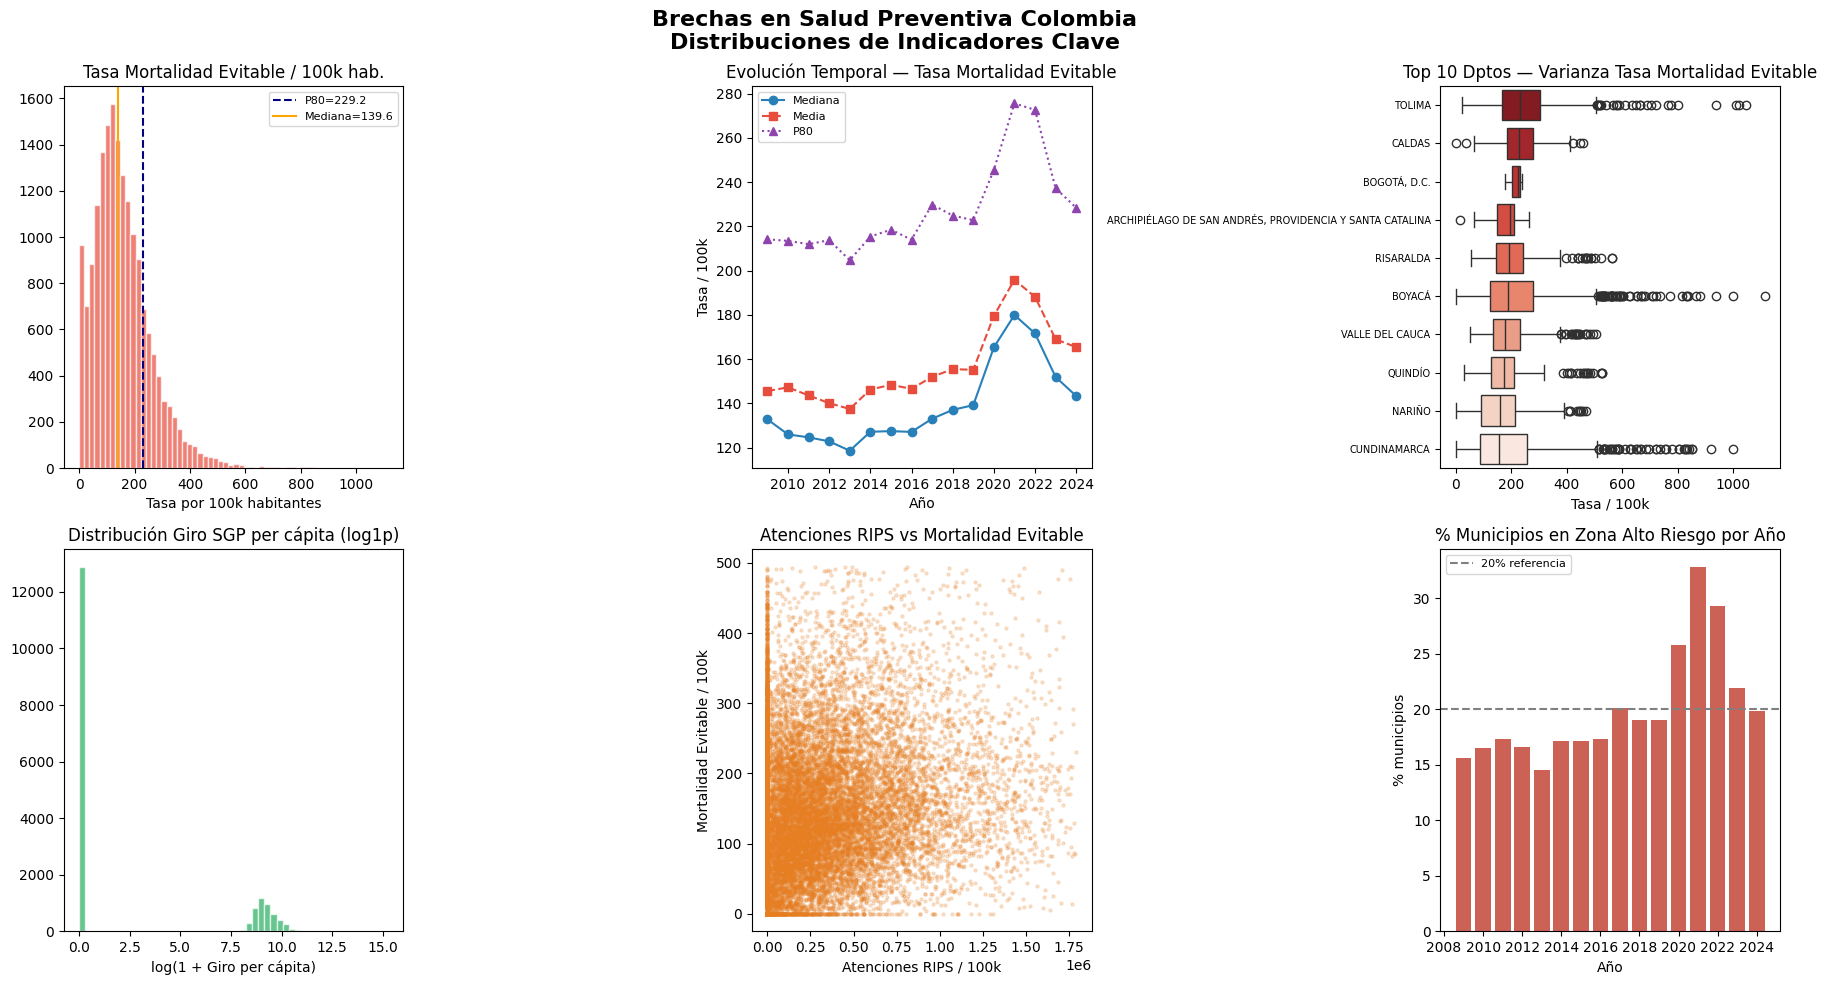

✅ Gráficas guardadas en output/distribucion_kpis.png


In [15]:
# ============================================================
# 7.4 DISTRIBUCIONES Y EVOLUCIÓN TEMPORAL
# ============================================================

def graficar_distribuciones(df):
    """Distribuciones de KPIs y evolución temporal por departamento."""

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(
        'Brechas en Salud Preventiva Colombia\nDistribuciones de Indicadores Clave',
        fontsize=16, fontweight='bold'
    )

    # ── Distribución tasa de mortalidad evitable ──────────────
    ax = axes[0, 0]
    data = df['TASA_MORTALIDAD_EVITABLE_100K'].dropna()
    ax.hist(data, bins=60, color='#E74C3C', alpha=0.7, edgecolor='white')
    ax.axvline(data.quantile(0.80), color='navy', linestyle='--',
               label=f'P80={data.quantile(0.80):.1f}')
    ax.axvline(data.median(), color='orange', linestyle='-',
               label=f'Mediana={data.median():.1f}')
    ax.set_title('Tasa Mortalidad Evitable / 100k hab.')
    ax.set_xlabel('Tasa por 100k habitantes')
    ax.legend(fontsize=8)

    # ── Evolución temporal tasa mortalidad evitable ───────────
    ax = axes[0, 1]
    evol = (
        df.groupby('ANIO')['TASA_MORTALIDAD_EVITABLE_100K']
        .agg(['median', 'mean', lambda x: x.quantile(0.80)])
        .reset_index()
    )
    evol.columns = ['ANIO', 'Mediana', 'Media', 'P80']
    ax.plot(evol['ANIO'], evol['Mediana'], 'o-', label='Mediana', color='#2980B9')
    ax.plot(evol['ANIO'], evol['Media'],   's--', label='Media', color='#E74C3C')
    ax.plot(evol['ANIO'], evol['P80'],     '^:', label='P80', color='#8E44AD')
    ax.set_title('Evolución Temporal — Tasa Mortalidad Evitable')
    ax.set_xlabel('Año')
    ax.set_ylabel('Tasa / 100k')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    # ── Boxplot por departamento (top 10 mayores tasas) ───────
    ax = axes[0, 2]
    top10_deptos = (
        df.groupby('NOM_DPTO')['TASA_MORTALIDAD_EVITABLE_100K']
        .median().nlargest(10).index.tolist()
    )
    df_top10 = df[df['NOM_DPTO'].isin(top10_deptos)]
    orden = (
        df_top10.groupby('NOM_DPTO')['TASA_MORTALIDAD_EVITABLE_100K']
        .median().sort_values(ascending=False).index
    )
    sns.boxplot(
        data=df_top10,
        x='TASA_MORTALIDAD_EVITABLE_100K', y='NOM_DPTO',
        order=orden, palette='Reds_r', ax=ax
    )
    ax.set_title('Top 10 Dptos — Varianza Tasa Mortalidad Evitable')
    ax.set_xlabel('Tasa / 100k')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=7)

    # ── Distribución Giro per cápita ──────────────────────────
    ax = axes[1, 0]
    data_g = df['GIRO_PER_CAPITA'].dropna()
    ax.hist(np.log1p(data_g), bins=50, color='#27AE60', alpha=0.7, edgecolor='white')
    ax.set_title('Distribución Giro SGP per cápita (log1p)')
    ax.set_xlabel('log(1 + Giro per cápita)')

    # ── Tasa atenciones RIPS vs mortalidad evitable ───────────
    ax = axes[1, 1]
    df_s = df[['TASA_ATENCIONES_RIPS_100K', 'TASA_MORTALIDAD_EVITABLE_100K']].dropna()
    df_s = df_s[
        (df_s['TASA_ATENCIONES_RIPS_100K'] < df_s['TASA_ATENCIONES_RIPS_100K'].quantile(0.99)) &
        (df_s['TASA_MORTALIDAD_EVITABLE_100K'] < df_s['TASA_MORTALIDAD_EVITABLE_100K'].quantile(0.99))
    ]
    ax.scatter(
        df_s['TASA_ATENCIONES_RIPS_100K'],
        df_s['TASA_MORTALIDAD_EVITABLE_100K'],
        alpha=0.2, s=5, color='#E67E22'
    )
    ax.set_title('Atenciones RIPS vs Mortalidad Evitable')
    ax.set_xlabel('Atenciones RIPS / 100k')
    ax.set_ylabel('Mortalidad Evitable / 100k')

    # ── % Municipios Alto Riesgo por año ──────────────────────
    ax = axes[1, 2]
    alto_riesgo = (
        df[df['FLG_ZONA_ALTO_RIESGO'].notna()]
        .groupby('ANIO')['FLG_ZONA_ALTO_RIESGO']
        .agg(lambda x: (x == 1).sum() / len(x) * 100)
        .reset_index(name='PCT_ALTO_RIESGO')
    )
    ax.bar(alto_riesgo['ANIO'], alto_riesgo['PCT_ALTO_RIESGO'],
           color='#C0392B', alpha=0.8)
    ax.axhline(20, linestyle='--', color='gray', label='20% referencia')
    ax.set_title('% Municipios en Zona Alto Riesgo por Año')
    ax.set_xlabel('Año')
    ax.set_ylabel('% municipios')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig(os.path.join(str(OUTPUT_DIR), 'distribucion_kpis.png'),
                dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ Gráficas guardadas en output/distribucion_kpis.png')


graficar_distribuciones(df_hechos)

=== 📐 ANÁLISIS DE VARIANZA POR DEPARTAMENTO ===
  Top 10 departamentos con mayor coeficiente de variación (CV):


,NOM_DPTO,MEDIA,MEDIANA,STD,CV_PCT,IQR,MIN,MAX,N
28,AMAZONAS,30.45,0.00,42.51,139.60,55.06,0.00,183.65,127
31,VAUPÉS,31.64,23.90,40.71,128.70,49.63,0.00,205.27,79
11,CHOCÓ,51.31,24.95,60.53,118.00,70.51,0.00,282.65,457
13,LA GUAJIRA,81.54,58.78,90.97,111.60,79.89,0.00,532.89,239
29,GUAINÍA,47.43,43.78,48.29,101.80,84.66,0.00,155.12,66
9,CÓRDOBA,104.06,92.17,81.92,78.70,91.94,0.00,467.25,473
32,VICHADA,76.70,82.74,56.53,73.70,98.88,0.00,211.41,64
26,PUTUMAYO,106.05,91.51,78.01,73.60,76.28,6.82,578.87,208
10,CUNDINAMARCA,187.45,157.11,137.37,73.30,169.11,0.00,"1,001.06",1842
7,CAUCA,106.39,96.03,75.84,71.30,97.91,0.00,403.19,672


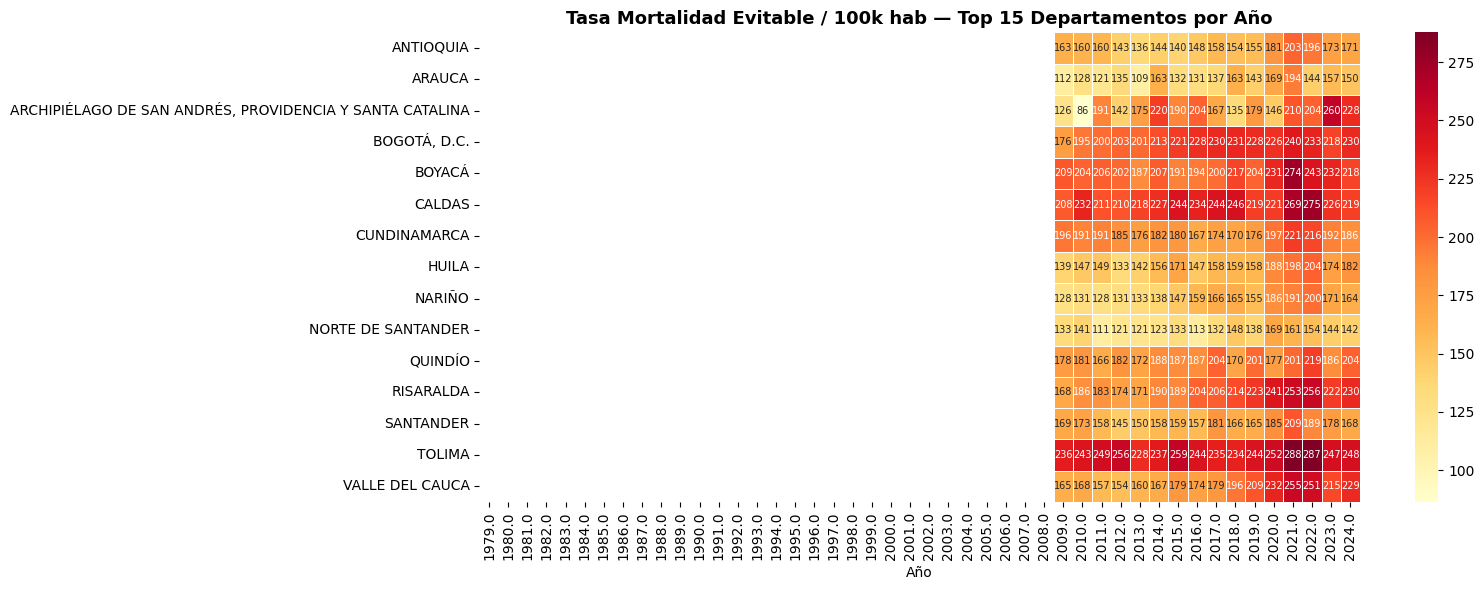

✅ Heatmap guardado en output/heatmap_dpto_anio.png


In [16]:
# ============================================================
# 7.5 VARIANZA Y COEFICIENTE DE VARIACIÓN POR DEPARTAMENTO
# ============================================================

def analizar_varianza(df):
    """Calcula varianza, desvío estándar y CV para KPIs por departamento."""

    print('=== 📐 ANÁLISIS DE VARIANZA POR DEPARTAMENTO ===')

    var_dep = (
        df.groupby(['COD_DPTO', 'NOM_DPTO'])['TASA_MORTALIDAD_EVITABLE_100K']
        .agg(
            MEDIA    = 'mean',
            MEDIANA  = 'median',
            STD      = 'std',
            VARIANZA = 'var',
            MIN      = 'min',
            MAX      = 'max',
            P25      = lambda x: x.quantile(0.25),
            P75      = lambda x: x.quantile(0.75),
            N        = 'count',
        )
        .reset_index()
    )
    var_dep['CV_PCT'] = (var_dep['STD'] / var_dep['MEDIA'].replace(0, np.nan) * 100).round(1)
    var_dep['IQR']    = (var_dep['P75'] - var_dep['P25']).round(2)
    var_dep = var_dep.sort_values('CV_PCT', ascending=False)

    print('  Top 10 departamentos con mayor coeficiente de variación (CV):')
    display(
        var_dep.head(10)[
            ['NOM_DPTO', 'MEDIA', 'MEDIANA', 'STD', 'CV_PCT', 'IQR', 'MIN', 'MAX', 'N']
        ].round(2)
    )

    # Heatmap de tasa promedio por departamento-año (top 15 dptos)
    top15_dptos = (
        df.groupby('NOM_DPTO')['TASA_MORTALIDAD_EVITABLE_100K']
        .mean().nlargest(15).index.tolist()
    )
    pivot_hm = (
        df[df['NOM_DPTO'].isin(top15_dptos)]
        .groupby(['NOM_DPTO', 'ANIO'])['TASA_MORTALIDAD_EVITABLE_100K']
        .mean()
        .unstack('ANIO')
    )

    fig, ax = plt.subplots(figsize=(16, 6))
    sns.heatmap(
        pivot_hm.round(1), annot=True, fmt='.0f', cmap='YlOrRd',
        linewidths=0.5, ax=ax, annot_kws={'size': 7}
    )
    ax.set_title(
        'Tasa Mortalidad Evitable / 100k hab — Top 15 Departamentos por Año',
        fontsize=13, fontweight='bold'
    )
    ax.set_xlabel('Año')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(os.path.join(str(OUTPUT_DIR), 'heatmap_dpto_anio.png'),
                dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ Heatmap guardado en output/heatmap_dpto_anio.png')
    return var_dep


df_varianza = analizar_varianza(df_hechos)

## 9. EXPORTACIÓN TABLA DE HECHOS

In [17]:
# ============================================================
# 8. EXPORTACIÓN DE LA TABLA DE HECHOS
# ============================================================

def exportar_tabla_hechos(df, path_output):
    """
    Exporta la tabla de hechos a formato Parquet (compresión snappy).
    Imprime resumen final del artefacto generado.
    """
    print('💾 Exportando tabla de hechos...')

    # Coerce tipos problemáticos antes de exportar
    for col in df.select_dtypes(include=['Int8', 'Int64']).columns:
        df[col] = df[col].astype('float64')

    df.to_parquet(str(path_output), index=False, compression='snappy')

    file_size = os.path.getsize(str(path_output)) / 1e6
    print(f'\n✅ Archivo exportado: {path_output}')
    print(f'   Tamaño: {file_size:.1f} MB')
    print(f'   Filas:  {len(df):,}')
    print(f'   Columnas: {df.shape[1]}')
    print('\n📋 Columnas del artefacto final:')
    for i, col in enumerate(df.columns, 1):
        print(f'  {i:2}. {col} ({df[col].dtype})')

    return path_output


path_final = exportar_tabla_hechos(df_hechos, OUTPUT_TABLA_HECHOS)

# Verificación de lectura
print('\n🔍 Verificación de lectura del parquet exportado...')
df_check = pd.read_parquet(str(path_final))
print(f'  Filas leídas: {len(df_check):,} ✅' if len(df_check) == len(df_hechos) else '  ❌ Discrepancia en filas')
print(f'  Sample:')
display(df_check.head(3))

💾 Exportando tabla de hechos...

✅ Archivo exportado: /kaggle/working/tabla_hechos_salud_colombia.parquet
   Tamaño: 2.3 MB
   Filas:  48,588
   Columnas: 43

📋 Columnas del artefacto final:
   1. COD_MPIO (object)
   2. ANIO (float64)
   3. COD_DPTO (object)
   4. NOM_DPTO (object)
   5. NOM_MPIO (object)
   6. LONGITUD (float64)
   7. LATITUD (float64)
   8. GEOMETRIA_PUNTO_WKT (object)
   9. TASA_MORTALIDAD_EVITABLE_100K (float64)
  10. FLG_ZONA_ALTO_RIESGO (float64)
  11. TOTAL_FALLECIDOS (float64)
  12. MUERTES_ATRIBUIBLES (float64)
  13. PCT_ATRIBUIBLE (float64)
  14. TASA_MORTALIDAD_TOTAL_100K (float64)
  15. SEMESTRE (float64)
  16. POBLACION_TOTAL (float64)
  17. TIPO_DATO_POB (float64)
  18. TOTAL_ATENCIONES_RIPS (float64)
  19. TASA_ATENCIONES_RIPS_100K (float64)
  20. VALOR_GIRADO_TOTAL (float64)
  21. VALOR_GIRADO_NORMAL (float64)
  22. GIRO_PER_CAPITA (float64)
  23. N_GIROS (float64)
  24. N_GIROS_ATIPICOS (float64)
  25. GIRO_PROMEDIO_MES (float64)
  26. TOTAL_EVENTOS_S

,COD_MPIO,ANIO,COD_DPTO,NOM_DPTO,NOM_MPIO,LONGITUD,LATITUD,GEOMETRIA_PUNTO_WKT,TASA_MORTALIDAD_EVITABLE_100K,FLG_ZONA_ALTO_RIESGO,TOTAL_FALLECIDOS,MUERTES_ATRIBUIBLES,PCT_ATRIBUIBLE,TASA_MORTALIDAD_TOTAL_100K,SEMESTRE,POBLACION_TOTAL,TIPO_DATO_POB,TOTAL_ATENCIONES_RIPS,TASA_ATENCIONES_RIPS_100K,VALOR_GIRADO_TOTAL,VALOR_GIRADO_NORMAL,GIRO_PER_CAPITA,N_GIROS,N_GIROS_ATIPICOS,GIRO_PROMEDIO_MES,TOTAL_EVENTOS_SIVIGILA,N_TIPOS_EVENTO,TASA_SIVIGILA_100K,BDUA_TOTAL_AFILIADOS,BDUA_N_ENTIDADES,PCT_AFILIACION,N_REGISTROS_DEF,RIPS_CONSULTAS,RIPS_HOSPITALIZACIONES,RIPS_PROCEDIMIENTOS_DE_SALUD,RIPS_URGENCIAS,BDUA_FEMENINO,BDUA_MASCULINO,BDUA_REG_SUBSIDIADO,PCT_CONSULTAS_100K,PCT_HOSPITALIZACIONES_100K,PCT_PROCEDIMIENTOS_DE_SALUD_100K,PCT_URGENCIAS_100K
0,05001,"1,979.00",05,ANTIOQUIA,MEDELLÍN,-75.58,6.25,POINT (-75.581775 6.246631),NaN,NaN,"8,835.00","3,463.00",0.39,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"868,890.00",14.00,NaN,"8,253.00",NaN,NaN,NaN,NaN,"447,055.00","421,835.00","868,890.00",NaN,NaN,NaN,NaN
1,05001,"1,980.00",05,ANTIOQUIA,MEDELLÍN,-75.58,6.25,POINT (-75.581775 6.246631),NaN,NaN,"9,455.00","3,661.00",0.39,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"868,890.00",14.00,NaN,"8,679.00",NaN,NaN,NaN,NaN,"447,055.00","421,835.00","868,890.00",NaN,NaN,NaN,NaN
2,05001,"1,981.00",05,ANTIOQUIA,MEDELLÍN,-75.58,6.25,POINT (-75.581775 6.246631),NaN,NaN,"9,798.00","3,926.00",0.40,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"868,890.00",14.00,NaN,"8,929.00",NaN,NaN,NaN,NaN,"447,055.00","421,835.00","868,890.00",NaN,NaN,NaN,NaN


## 10. RESUMEN PIPELINE

In [18]:
# ============================================================
# 9. RESUMEN EJECUTIVO
# ============================================================

def resumen_ejecutivo(df, errores_val):
    """Imprime resumen final del pipeline ETL y la tabla de hechos."""

    print('=' * 65)
    print('    RESUMEN EJECUTIVO — PIPELINE ETL SALUD COLOMBIA')
    print('=' * 65)

    print(f'''
📦 TABLA DE HECHOS GENERADA:
   • Granularidad   : Municipio × Año
   • Filas totales  : {len(df):,}
   • Columnas       : {df.shape[1]}
   • Municipios     : {df["COD_MPIO"].nunique():,}
   • Rango años     : {int(df["ANIO"].min())} – {int(df["ANIO"].max())}

🎯 VARIABLES OBJETIVO:
   • Regresión     : TASA_MORTALIDAD_EVITABLE_100K
     Media={df["TASA_MORTALIDAD_EVITABLE_100K"].mean():.1f}  | Mediana={df["TASA_MORTALIDAD_EVITABLE_100K"].median():.1f}  | P80={df["TASA_MORTALIDAD_EVITABLE_100K"].quantile(0.80):.1f}
   • Clasificación : FLG_ZONA_ALTO_RIESGO (≥P80)
     Alto riesgo={int(df["FLG_ZONA_ALTO_RIESGO"].sum()):,} ({df["FLG_ZONA_ALTO_RIESGO"].mean()*100:.1f}%)

📂 FUENTES INTEGRADAS:
   • Defunciones DANE  (1979–2024)  ✅
   • RIPS              (2009–2021)  ✅
   • Giros SGP         (2015–2023)  ✅
   • SIVIGILA          (2021)       ✅ (corte transversal, NaN esperados)
   • BDUA              (S/F)        ✅ (estático, join por municipio)
   • Población DANE    (1985–2042)  ✅
   • DIVIPOLA          (vigente)    ✅

⚠️  RESTRICCIONES CONOCIDAS:
   • SIVIGILA solo cubre 2021 → alta tasa de NaN en años restantes
   • BDUA sin año → feature estática por municipio
   • Giros disponibles 2015–2023 → NaN en años anteriores
   • RIPS disponible 2009–2021 → NaN en años fuera de rango
   • Mes en defunciones: agrupado anualmente (diseño del dataset)

✅ VALIDACIONES: {len(errores_val)} errores críticos detectados
{''.join([chr(10)+"   ❌ "+e for e in errores_val]) if errores_val else '   Todas las validaciones pasaron correctamente.'}
''')

    print('=' * 65)


resumen_ejecutivo(df_hechos, errores_val)

    RESUMEN EJECUTIVO — PIPELINE ETL SALUD COLOMBIA

📦 TABLA DE HECHOS GENERADA:
   • Granularidad   : Municipio × Año
   • Filas totales  : 48,588
   • Columnas       : 43
   • Municipios     : 1,122
   • Rango años     : 1979 – 2024

🎯 VARIABLES OBJETIVO:
   • Regresión     : TASA_MORTALIDAD_EVITABLE_100K
     Media=157.3  | Mediana=139.6  | P80=229.2
   • Clasificación : FLG_ZONA_ALTO_RIESGO (≥P80)
     Alto riesgo=3,541 (20.0%)

📂 FUENTES INTEGRADAS:
   • Defunciones DANE  (1979–2024)  ✅
   • RIPS              (2009–2021)  ✅
   • Giros SGP         (2015–2023)  ✅
   • SIVIGILA          (2021)       ✅ (corte transversal, NaN esperados)
   • BDUA              (S/F)        ✅ (estático, join por municipio)
   • Población DANE    (1985–2042)  ✅
   • DIVIPOLA          (vigente)    ✅

⚠️  RESTRICCIONES CONOCIDAS:
   • SIVIGILA solo cubre 2021 → alta tasa de NaN en años restantes
   • BDUA sin año → feature estática por municipio
   • Giros disponibles 2015–2023 → NaN en años anteriores
   

## 11. PREPARACIÓN MODELOS ML

In [19]:
# ============================================================
# 10. PREPARACIÓN INICIAL PARA MODELOS
# (Feature selection, sets de entrenamiento / prueba)
# ============================================================

def preparar_features(df):
    """
    Prepara el dataset para modelado:
    - Selecciona features numéricas relevantes
    - Reporta correlaciones con las variables objetivo
    - Sugiere split temporal (out-of-time testing)
    """
    print('=== 🤖 PREPARACIÓN PARA MODELOS ===')

    FEATURES = [
        'POBLACION_TOTAL', 'TOTAL_FALLECIDOS', 'MUERTES_ATRIBUIBLES',
        'TOTAL_ATENCIONES_RIPS', 'TASA_ATENCIONES_RIPS_100K',
        'VALOR_GIRADO_TOTAL', 'GIRO_PER_CAPITA', 'VALOR_GIRADO_NORMAL',
        'N_GIROS', 'N_GIROS_ATIPICOS',
        'TOTAL_EVENTOS_SIVIGILA', 'TASA_SIVIGILA_100K',
        'BDUA_TOTAL_AFILIADOS', 'BDUA_N_ENTIDADES', 'PCT_AFILIACION',
        'ANIO',
    ]
    TARGETS_REG   = 'TASA_MORTALIDAD_EVITABLE_100K'
    TARGETS_CLSF  = 'FLG_ZONA_ALTO_RIESGO'

    features_presentes = [f for f in FEATURES if f in df.columns]

    # Correlación con variable objetivo de regresión
    print('\n📊 Correlación con TASA_MORTALIDAD_EVITABLE_100K:')
    corr = (
        df[features_presentes + [TARGETS_REG]]
        .corr()[TARGETS_REG]
        .drop(TARGETS_REG)
        .sort_values(key=abs, ascending=False)
    )
    display(corr.round(3))

    # Split temporal: entrenamiento hasta 2019, prueba 2020+
    # (out-of-time testing para evitar data leakage)
    ANIO_CORTE = 2019
    df_train = df[df['ANIO'] <= ANIO_CORTE].copy()
    df_test  = df[df['ANIO'] >  ANIO_CORTE].copy()

    print(f'\n✂️  Split temporal (out-of-time):')
    print(f'  Train: ≤ {ANIO_CORTE} → {len(df_train):,} filas')
    print(f'  Test:  > {ANIO_CORTE} → {len(df_test):,} filas')

    # Guardar conjuntos
    df_train.to_parquet(
        os.path.join(str(OUTPUT_DIR), 'tabla_hechos_train.parquet'),
        index=False, compression='snappy'
    )
    df_test.to_parquet(
        os.path.join(str(OUTPUT_DIR), 'tabla_hechos_test.parquet'),
        index=False, compression='snappy'
    )
    print('✅ Conjuntos train/test guardados.')

    return features_presentes, corr


features, correlaciones = preparar_features(df_hechos)

=== 🤖 PREPARACIÓN PARA MODELOS ===

📊 Correlación con TASA_MORTALIDAD_EVITABLE_100K:


MUERTES_ATRIBUIBLES          0.18
TOTAL_FALLECIDOS             0.17
BDUA_TOTAL_AFILIADOS         0.16
TASA_ATENCIONES_RIPS_100K    0.14
N_GIROS_ATIPICOS             0.14
TOTAL_EVENTOS_SIVIGILA       0.13
VALOR_GIRADO_TOTAL           0.13
ANIO                         0.12
BDUA_N_ENTIDADES             0.11
TOTAL_ATENCIONES_RIPS        0.11
VALOR_GIRADO_NORMAL         -0.11
POBLACION_TOTAL              0.10
PCT_AFILIACION              -0.09
N_GIROS                     -0.06
TASA_SIVIGILA_100K           0.04
GIRO_PER_CAPITA              0.01
Name: TASA_MORTALIDAD_EVITABLE_100K, dtype: float64


✂️  Split temporal (out-of-time):
  Train: ≤ 2019 → 43,022 filas
  Test:  > 2019 → 5,566 filas
✅ Conjuntos train/test guardados.


In [20]:
# ============================================================
# EJECUCIÓN COMPLETA (Celda de orquestación)
# Ejecutar esta celda para correr el pipeline completo de punta a punta.
# ============================================================

def ejecutar_pipeline_completo():
    """Orquesta el pipeline ETL completo de punta a punta."""
    print('🚀 Iniciando pipeline ETL completo...\n')

    # Paso 1: Geografía de referencia
    print('1/7 Cargando DIVIPOLA...')
    geo = cargar_divipola(BASE_DIVIPOLA)

    # Paso 2: Población
    print('2/7 Cargando POBLACIÓN...')
    pob = cargar_poblacion(BASE_POBLACION)

    # Paso 3: Defunciones
    print('3/7 Cargando DEFUNCIONES...')
    def_ = cargar_defunciones(BASE_DEFUNCIONES)

    # Paso 4: RIPS
    print('4/7 Cargando RIPS...')
    rips = cargar_rips(BASE_RIPS)

    # Paso 5: GIROS
    print('5/7 Cargando GIROS...')
    giros = cargar_giros(BASE_GIROS)

    # Paso 6: SIVIGILA
    print('6/7 Cargando SIVIGILA...')
    siv = cargar_sivigila(BASE_SIVIGILA)

    # Paso 7: BDUA
    print('7/7 Cargando BDUA...')
    bdua = cargar_bdua(BASE_BDUA)

    # Construcción tabla hechos
    print('\n🔗 Construyendo tabla de hechos...')
    th = construir_tabla_hechos(def_, rips, giros, siv, bdua, pob, geo)
    th = calcular_indicadores(th)

    # Validación
    errores = validar_tabla_hechos(th)

    # Exportar
    exportar_tabla_hechos(th, OUTPUT_TABLA_HECHOS)

    print('\n🏁 Pipeline completo finalizado.')
    return th, errores


# Descomentar para re-ejecutar todo desde cero:
# df_hechos, errores_val = ejecutar_pipeline_completo()

print('✅ Celda de orquestación lista.')
print('   Para re-ejecutar el pipeline completo, descomente la última línea.')

✅ Celda de orquestación lista.
   Para re-ejecutar el pipeline completo, descomente la última línea.
